In [57]:
#Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore') # Ignore warnings for cleaner output

In [58]:
df=pd.read_csv("insurance.csv") # Load the dataset into a pandas DataFrame

In [59]:
df # Display the DataFrame to see its contents

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [60]:
df.isna().sum() # Check for any missing values in each column

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [61]:
df.info() # Get a concise summary of the DataFrame, including data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [62]:
df.shape # Display the number of rows and columns in the DataFrame

(1338, 7)

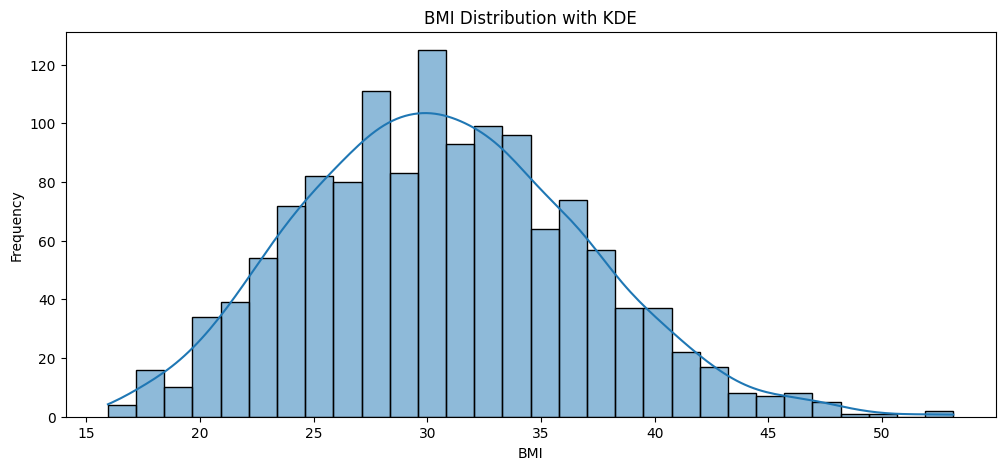

In [63]:
plt.figure(figsize=(12,5))
sns.histplot(df["bmi"],bins=30,kde=True) # Plot a histogram of the 'bmi' column with a Kernel Density Estimate
plt.title("BMI Distribution with KDE") # Set the title of the plot
plt.xlabel("BMI") # Set the x-axis label
plt.ylabel("Frequency") # Set the y-axis label
plt.show() # Display the plot

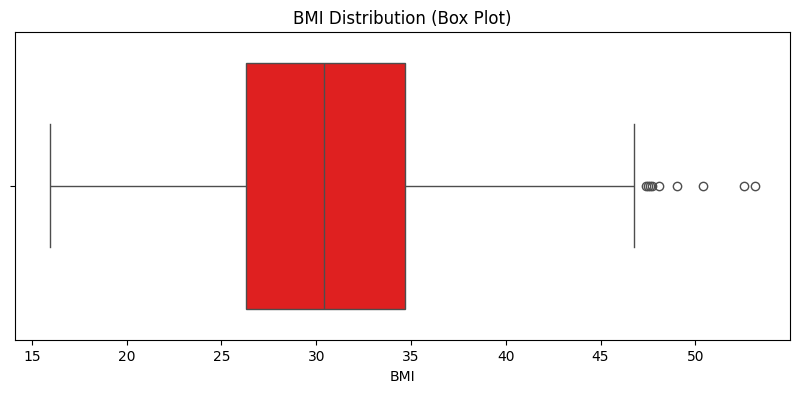

In [64]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["bmi"], color="red") # Create a box plot for the 'bmi' column to visualize its distribution and outliers
plt.title("BMI Distribution (Box Plot)") # Set the title of the plot
plt.xlabel("BMI") # Set the x-axis label
plt.show() # Display the plot

In [65]:
Q1=df["bmi"].quantile(0.25) # Calculate the first quartile (25th percentile) of 'bmi'
Q3=df["bmi"].quantile(0.75) # Calculate the third quartile (75th percentile) of 'bmi'
IQR=Q3-Q1 # Calculate the Interquartile Range (IQR)
lower_bound=Q1-1.5*IQR # Calculate the lower bound for outlier detection
upper_bound=Q3+1.5*IQR # Calculate the upper bound for outlier detection
outliers=df[(df["bmi"]<lower_bound) | (df["bmi"]>upper_bound)] # Identify outliers based on the calculated bounds
print(f"Lower bound of BMI: {lower_bound}") # Print the lower bound
print("_"*50)
print(f"Upper bound of BMI: {upper_bound}") # Print the upper bound
print("_"*50)
print("Outliers in BMI:") # Print a header for the outliers
print(outliers) # Display the identified outliers
print("_"*50)
df_cleaned=df[(df["bmi"]>=lower_bound) & (df["bmi"]<=upper_bound)] # Create a new DataFrame with outliers removed
print("Cleaned DataFrame:") # Print a header for the cleaned DataFrame
print(df_cleaned) # Display the cleaned DataFrame

Lower bound of BMI: 13.7
__________________________________________________
Upper bound of BMI: 47.290000000000006
__________________________________________________
Outliers in BMI:
      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270
__________________________________________________
Cleaned DataFrame:
      age     sex     bmi  children smoker     region      charges
0      19  female  2

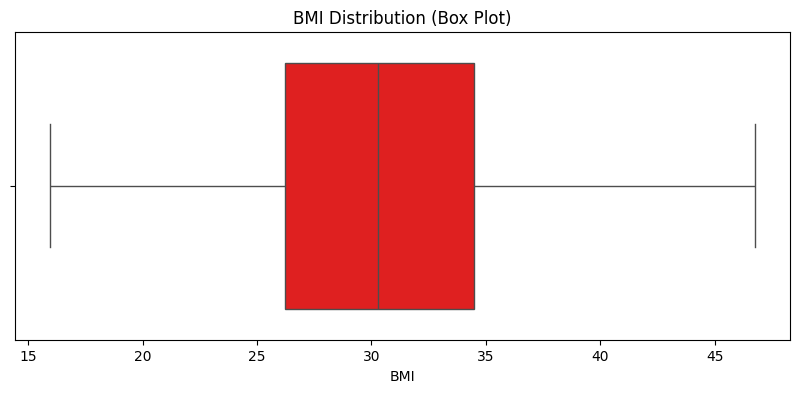

In [66]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_cleaned["bmi"], color="red") # Create a box plot for the 'bmi' column in the cleaned DataFrame
plt.title("BMI Distribution (Box Plot)") # Set the title of the plot
plt.xlabel("BMI") # Set the x-axis label
plt.show() # Display the plot

In [67]:
df_cleaned=pd.get_dummies(df_cleaned,drop_first=True) # Convert categorical variables into dummy/indicator variables, dropping the first category to avoid multicollinearity
df_cleaned.astype(int) # Convert the boolean dummy variables to integers (0 or 1)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30,3,10600,1,0,1,0,0
1334,18,31,0,2205,0,0,0,0,0
1335,18,36,0,1629,0,0,0,1,0
1336,21,25,0,2007,0,0,0,0,1


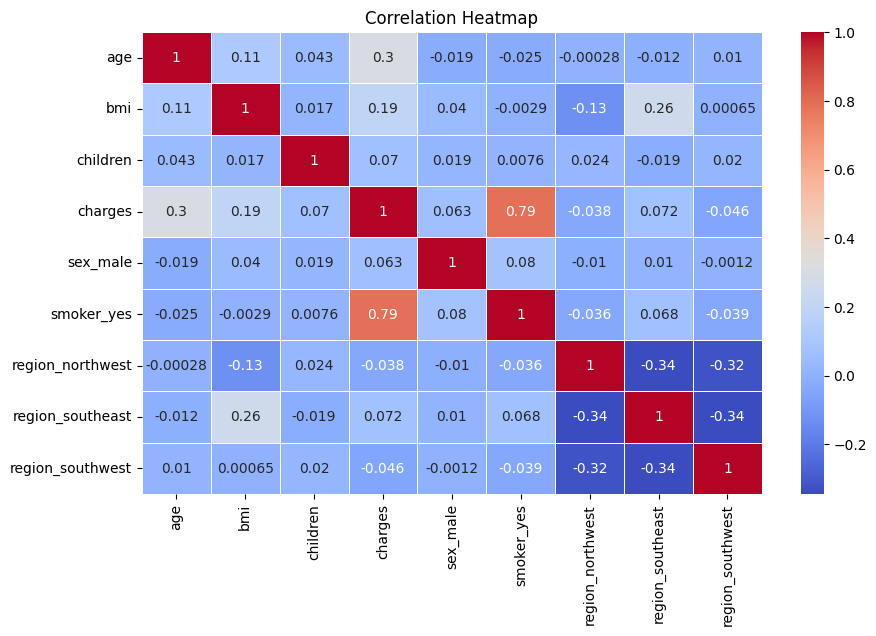

In [68]:
corr_matrix=df_cleaned.corr() # Calculate the correlation matrix for the cleaned DataFrame
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",linewidths=0.5) # Plot a heatmap of the correlation matrix with annotations
plt.title("Correlation Heatmap") # Set the title of the plot
plt.show() # Display the plot

In [69]:
X=df_cleaned[['age','bmi','children','smoker_yes']] # Define features (independent variables) for the model
y=df_cleaned['charges'] # Define the target variable (dependent variable) for the model

In [70]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=22) # Split the data into training and testing sets

In [71]:
model=LinearRegression() # Initialize a Linear Regression model
model.fit(x_train,y_train) # Train the model using the training data

LinearRegression()

In [72]:
y_pred=model.predict(x_test) # Make predictions on the test set
y_train_pred=model.predict(x_train) # Make predictions on the training set

In [73]:
print("Testing Accuracy:",np.round(r2_score(y_test,y_pred),2)) # Calculate and print the R2 score for the test set
print("Training Accuracy:",np.round(r2_score(y_train,y_train_pred),2)) # Calculate and print the R2 score for the training set

Testing Accuracy: 0.82
Training Accuracy: 0.73


In [74]:
best_random_state = 0
best_r2_score = -np.inf

for random_state_value in range(1, 201): # Iterate through random states from 1 to 200
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state_value) # Split data with current random state

    model = LinearRegression() # Initialize a new Linear Regression model
    model.fit(x_train, y_train) # Train the model

    y_pred = model.predict(x_test) # Make predictions on the test set
    current_r2_score = r2_score(y_test, y_pred) # Calculate the R2 score

    if current_r2_score > best_r2_score: # Check if current R2 score is better than the best found so far
        best_r2_score = current_r2_score # Update best R2 score
        best_random_state = random_state_value # Update best random state

print(f"The best random_state found is: {best_random_state}") # Print the best random state
print(f"With a testing R2 Score of: {np.round(best_r2_score, 2)}") # Print the corresponding best R2 score

The best random_state found is: 22
With a testing R2 Score of: 0.82


In [75]:
import pickle
with open('model_pickle.pkl','wb') as f: # Open a file in binary write mode
    pickle.dump(model,f) # Save the trained model to the file using pickle